<a href="https://colab.research.google.com/github/Heramb01/SC_CapstoneProject/blob/main/Room_4_Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv("student_performance_dataset.csv")

In [ ]:
print("First 5 Rows")
print(df.head())

First 5 Rows
  Student_ID  Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       S147    Male                    31        68.267841                86   
1       S136    Male                    16        78.222927                73   
2       S209  Female                    21        87.525096                74   
3       S458  Female                    27        92.076483                99   
4       S078  Female                    37        98.655517                63   

  Parental_Education_Level Internet_Access_at_Home Extracurricular_Activities  \
0              High School                     Yes                        Yes   
1                      PhD                      No                         No   
2                      PhD                     Yes                         No   
3                Bachelors                      No                         No   
4                  Masters                      No                        Yes   

   Final_Exam

In [ ]:
print("Dataset Shape")
print(df.shape)

Dataset Shape
(708, 10)


In [ ]:
print("Column Names")
print(df.columns)

Column Names
Index(['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'Parental_Education_Level',
       'Internet_Access_at_Home', 'Extracurricular_Activities',
       'Final_Exam_Score', 'Pass_Fail'],
      dtype='object')


In [ ]:
print("Dataset Info")
print(df.info())

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB
None


In [ ]:
print("Statistical Summary")
print(df.describe())

Statistical Summary
       Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
count            708.000000       708.000000        708.000000   
mean              26.132768        78.107722         77.871469   
std                8.877727        13.802802         14.402739   
min               10.000000        50.116970         50.000000   
25%               19.000000        67.550094         65.000000   
50%               27.000000        79.363046         79.000000   
75%               34.000000        89.504232         91.000000   
max               39.000000        99.967675        100.000000   

       Final_Exam_Score  
count        708.000000  
mean          58.771186  
std            6.705877  
min           50.000000  
25%           52.000000  
50%           59.500000  
75%           64.000000  
max           77.000000  


In [ ]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64


In [ ]:
print("Duplicate Rows")
print(df.duplicated().sum())

Duplicate Rows
208


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Duplicate Rows")
print(df.duplicated().sum())

Duplicate Rows
0


In [ ]:
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=np.number).columns
scaled_features = scaler.fit_transform(df[numerical_cols])

scaled_df = pd.DataFrame(scaled_features, columns=numerical_cols)

print("\nScaled Features")
print(scaled_df.head())


Scaled Features
   Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  Final_Exam_Score
0              0.661242        -0.541937          0.747277          1.057780
1             -1.044161         0.171423         -0.153725         -1.018804
2             -0.475694         0.837996         -0.084417         -0.220118
3              0.206467         1.164138          1.648278          1.377255
4              1.343403         1.635578         -0.846803          2.175941


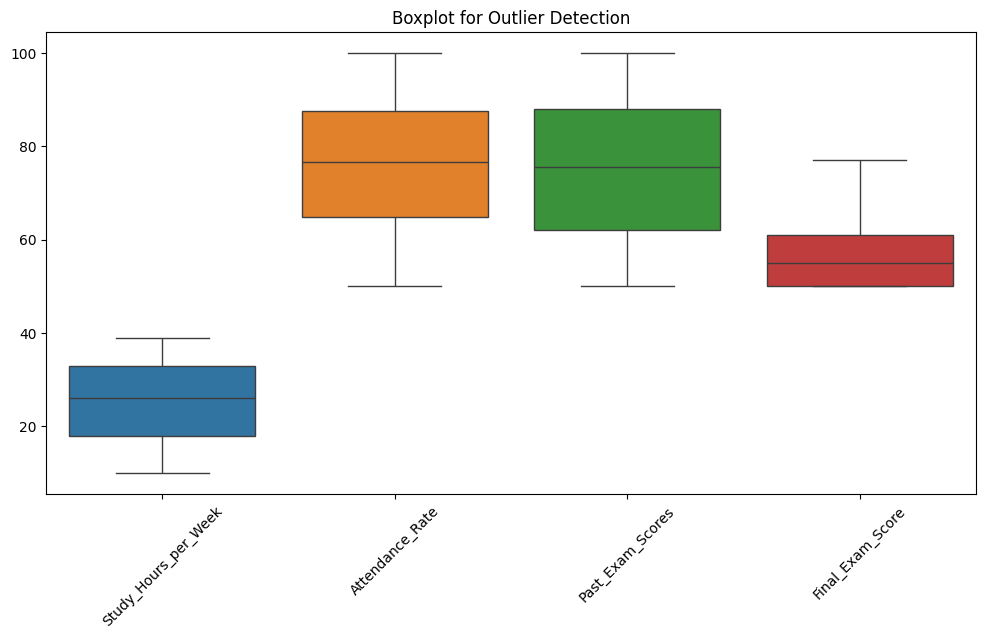

In [ ]:
# OUTLIER DETECTION

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

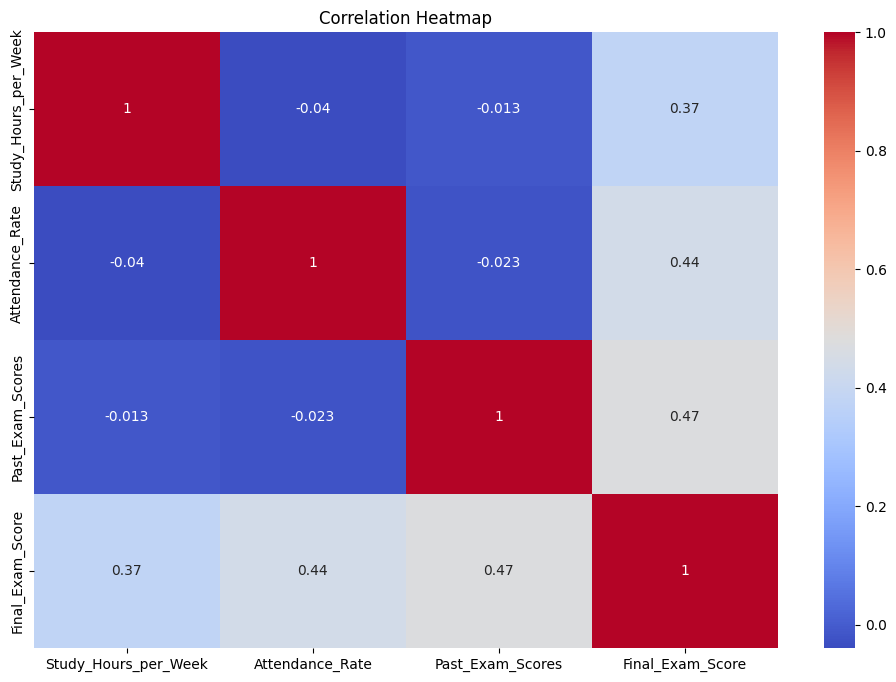

In [ ]:
# CORRELATION MATRIX

plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# EDA

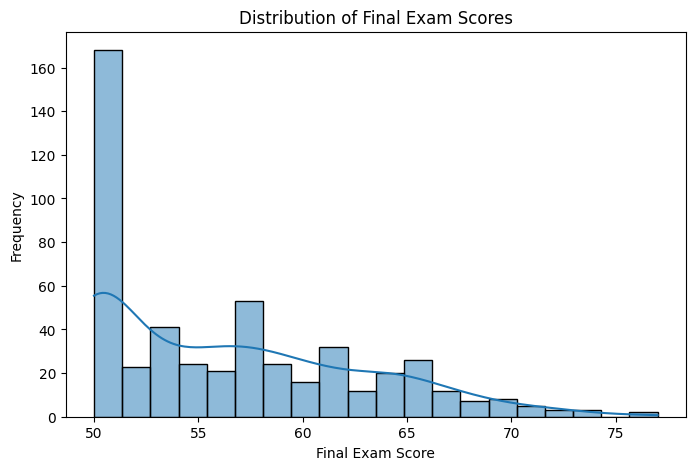

In [ ]:
# 1. FINAL EXAM SCORE DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['Final_Exam_Score'], bins=20, kde=True)
plt.title("Distribution of Final Exam Scores")
plt.xlabel("Final Exam Score")
plt.ylabel("Frequency")
plt.show()

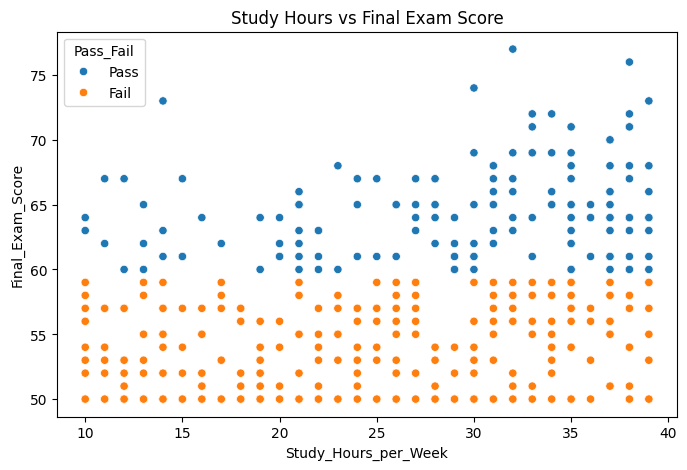

In [ ]:
# 3. STUDY HOURS VS FINAL SCORE

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Study_Hours_per_Week',
    y='Final_Exam_Score',
    hue='Pass_Fail',
    data=df
)
plt.title("Study Hours vs Final Exam Score")
plt.show()

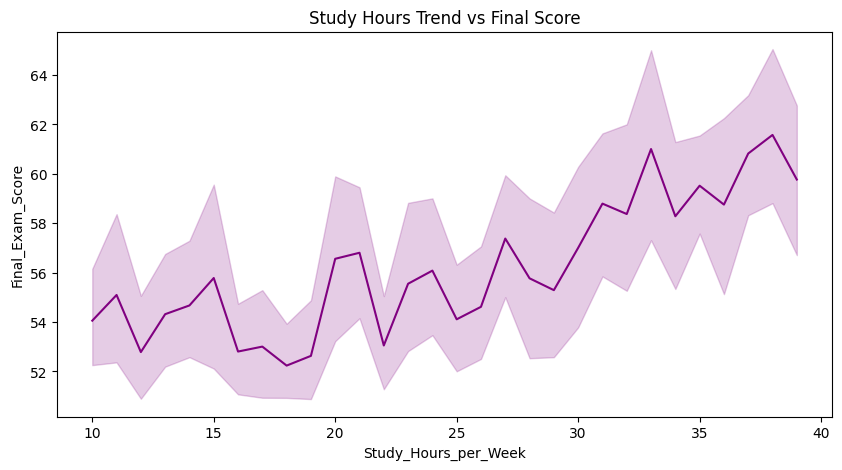

In [ ]:
# 6. LINE PLOT
#

sorted_df = df.sort_values(by='Study_Hours_per_Week')

plt.figure(figsize=(10,5))

sns.lineplot(
    x='Study_Hours_per_Week',
    y='Final_Exam_Score',
    data=sorted_df,
    color='purple'
)

plt.title("Study Hours Trend vs Final Score")
plt.show()


Students with higher study hours generally achieved better final exam scores, showing a positive correlation between effort and performance.

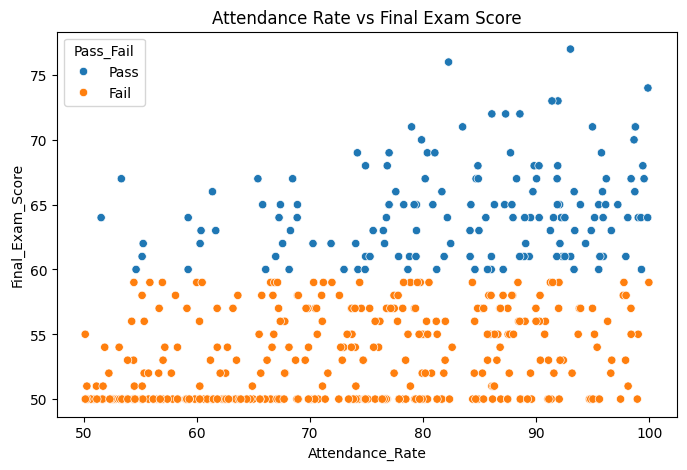

In [ ]:
# 4. ATTENDANCE VS FINAL SCORE

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Attendance_Rate',
    y='Final_Exam_Score',
    hue='Pass_Fail',
    data=df
)
plt.title("Attendance Rate vs Final Exam Score")
plt.show()

Higher attendance rates were associated with higher final exam scores.

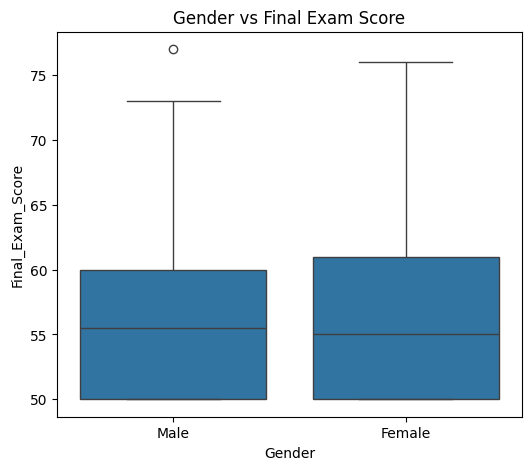

In [ ]:
# 5. GENDER-WISE PERFORMANCE

plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Final_Exam_Score', data=df)
plt.title("Gender vs Final Exam Score")
plt.show()


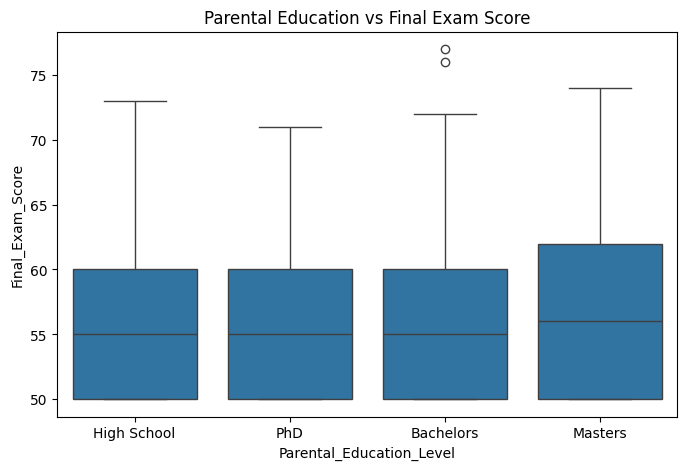

In [ ]:
# 6. PARENTAL EDUCATION IMPACT

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Parental_Education_Level',
    y='Final_Exam_Score',
    data=df
)
plt.title("Parental Education vs Final Exam Score")
plt.show()

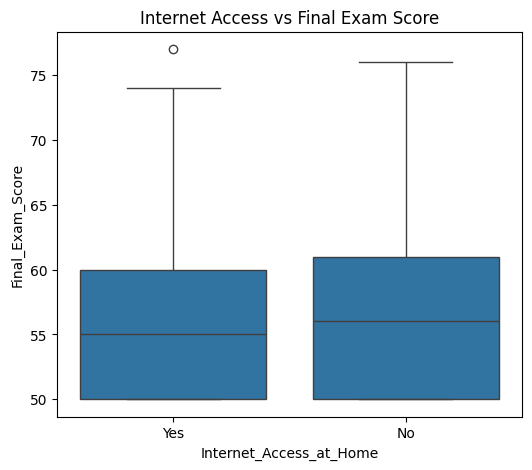

In [ ]:
# 7. INTERNET ACCESS IMPACT

plt.figure(figsize=(6,5))
sns.boxplot(
    x='Internet_Access_at_Home',
    y='Final_Exam_Score',
    data=df
)
plt.title("Internet Access vs Final Exam Score")
plt.show()


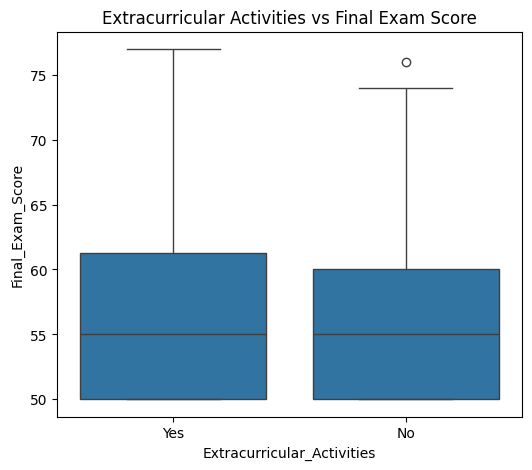

In [ ]:
# 8. EXTRACURRICULAR ACTIVITIES IMPACT

plt.figure(figsize=(6,5))
sns.boxplot(
    x='Extracurricular_Activities',
    y='Final_Exam_Score',
    data=df
)
plt.title("Extracurricular Activities vs Final Exam Score")
plt.show()

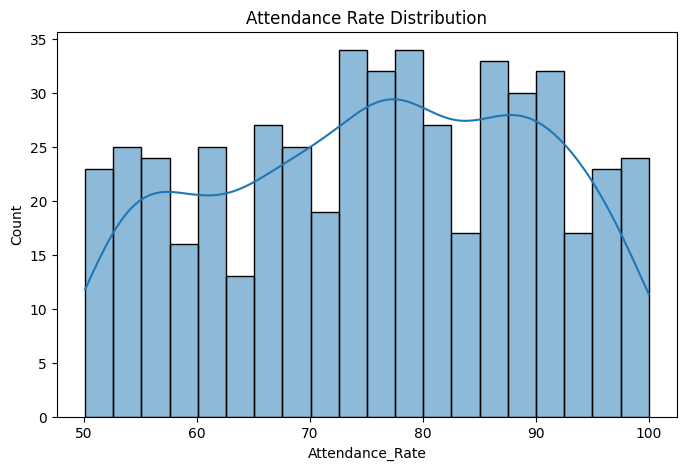

In [ ]:
# 9. ATTENDANCE DISTRIBUTION
# ======================

plt.figure(figsize=(8,5))
sns.histplot(df['Attendance_Rate'], bins=20, kde=True)
plt.title("Attendance Rate Distribution")
plt.show()


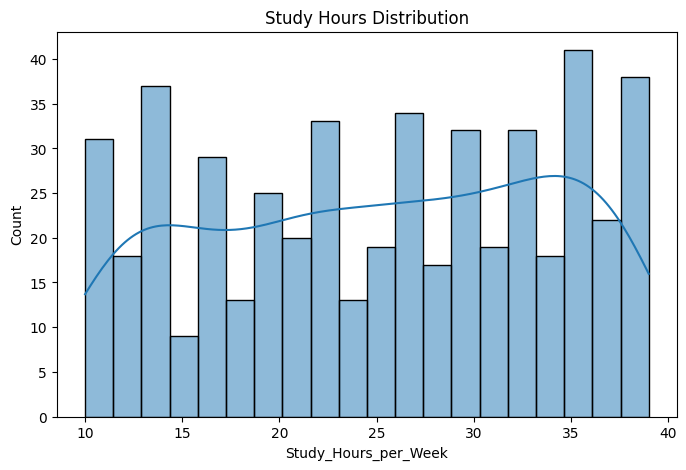

In [ ]:
# 10. STUDY HOURS DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['Study_Hours_per_Week'], bins=20, kde=True)
plt.title("Study Hours Distribution")
plt.show()

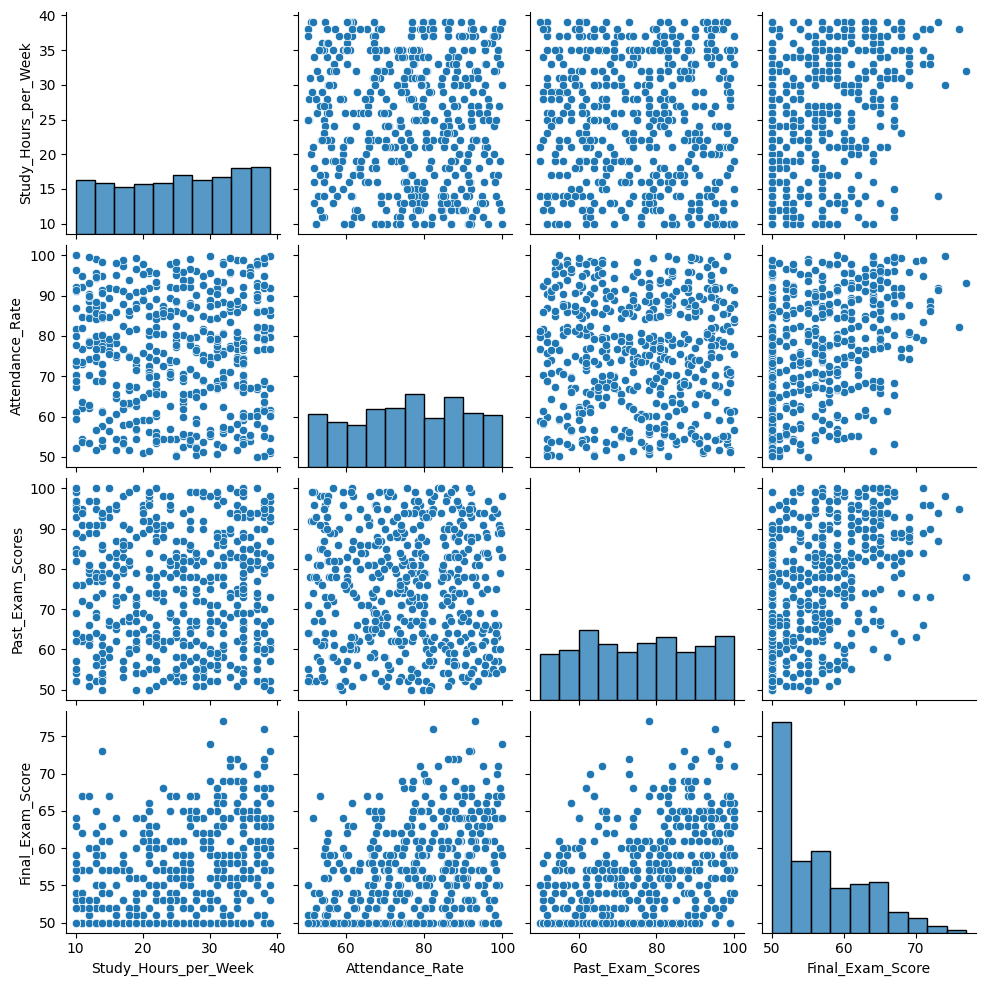

In [ ]:
# 11. PAIRPLOT

sns.pairplot(df)
plt.show()

Pairplot visualization revealed relationships among multiple variables, especially strong relationships between attendance, study hours, past scores, and final scores.

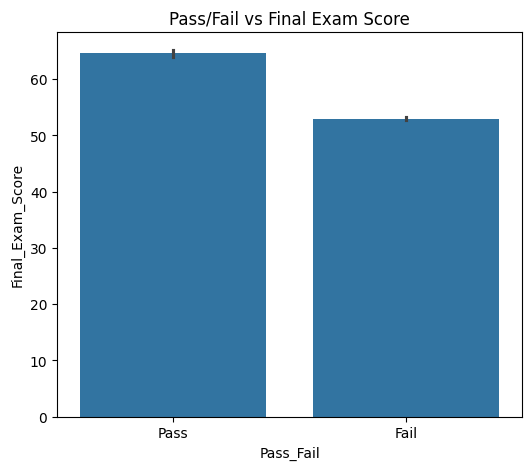

In [ ]:
# 12. FINAL SCORE BY PASS/FAIL

plt.figure(figsize=(6,5))
sns.barplot(x='Pass_Fail', y='Final_Exam_Score', data=df)
plt.title("Pass/Fail vs Final Exam Score")
plt.show()

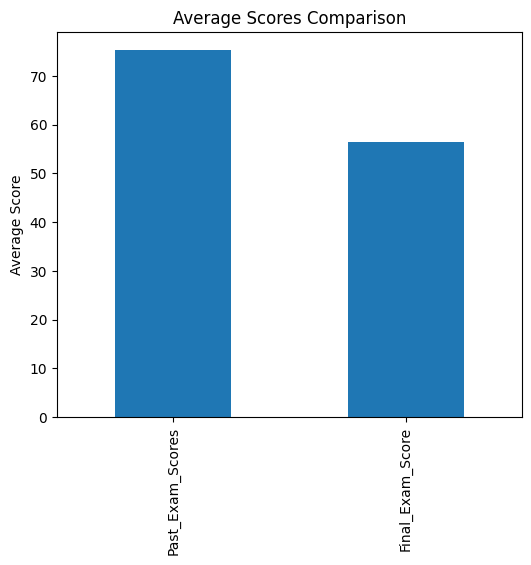

In [ ]:
# 13. AVERAGE SCORES COMPARISON

average_scores = df[[
    'Past_Exam_Scores',
    'Final_Exam_Score'
]].mean()

plt.figure(figsize=(6,5))
average_scores.plot(kind='bar')
plt.title("Average Scores Comparison")
plt.ylabel("Average Score")
plt.show()


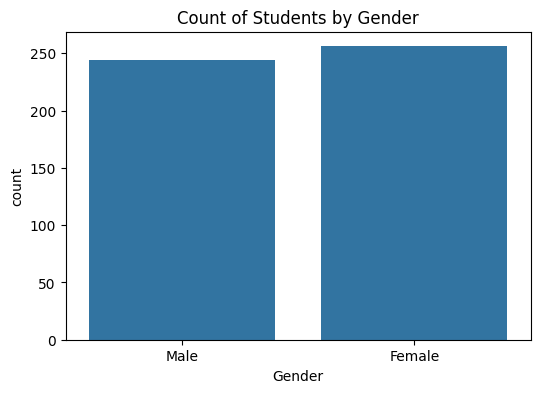

In [ ]:
# 14. COUNT OF STUDENTS BY GENDER

plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Count of Students by Gender")
plt.show()


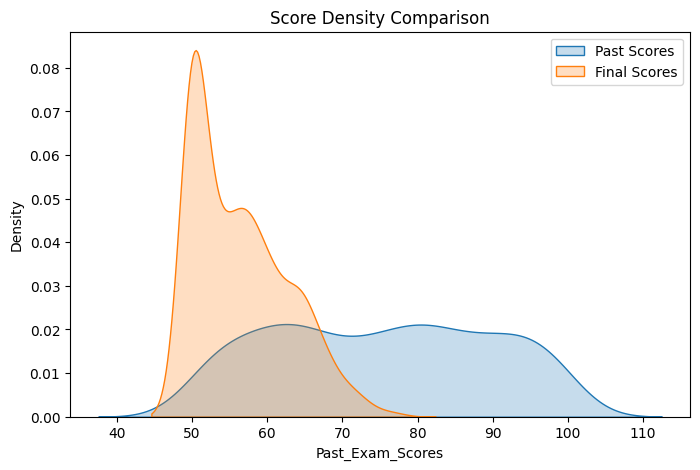

In [ ]:
# 15. KDE PLOT OF SCORES

plt.figure(figsize=(8,5))
sns.kdeplot(df['Past_Exam_Scores'], label='Past Scores', fill=True)
sns.kdeplot(df['Final_Exam_Score'], label='Final Scores', fill=True)
plt.title("Score Density Comparison")
plt.legend()
plt.show()


Insight:
Density plots showed how student scores are distributed and whether
performance patterns are concentrated or spread out.

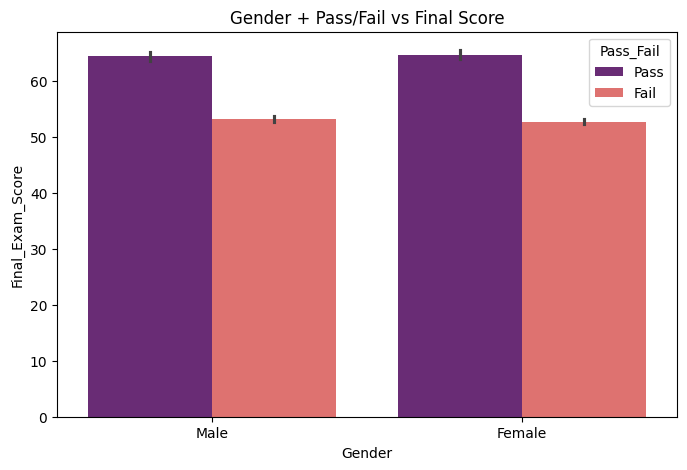

In [ ]:
# 10. SUNBURST STYLE BARPLOT
#

plt.figure(figsize=(8,5))

sns.barplot(
    x='Gender',
    y='Final_Exam_Score',
    hue='Pass_Fail',
    data=df,
    palette='magma'
)

plt.title("Gender + Pass/Fail vs Final Score")
plt.show()

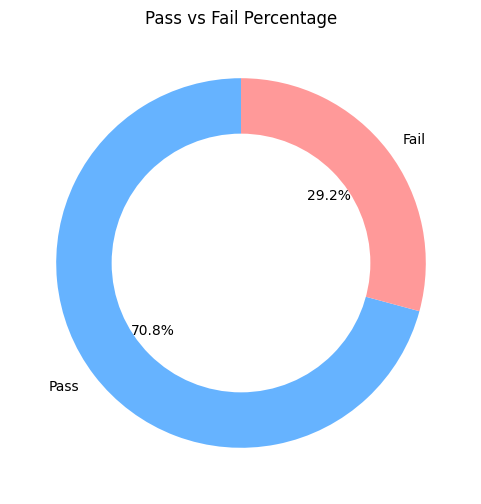

In [ ]:
# 5. DONUT CHART
#

pass_fail_counts = df['Pass_Fail'].value_counts()

plt.figure(figsize=(6,6))

colors = ['#66b3ff', '#ff9999']

plt.pie(
    pass_fail_counts,
    labels=['Pass', 'Fail'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Pass vs Fail Percentage")
plt.show()


/tmp/ipykernel_8110/3362065530.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


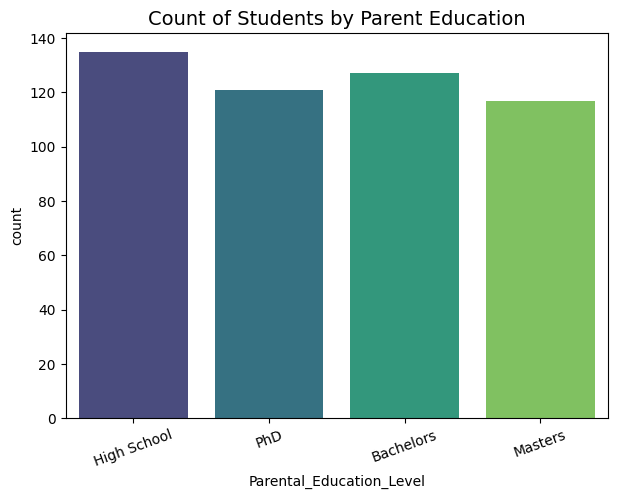

In [ ]:
# 4. COUNT PLOT
#

plt.figure(figsize=(7,5))

sns.countplot(
    x='Parental_Education_Level',
    data=df,
    palette='viridis'
)

plt.title("Count of Students by Parent Education", fontsize=14)
plt.xticks(rotation=20)
plt.show()

Insight:
The heatmap shows the strength and direction of relationships between all numerical variables in the dataset.

Key Findings:
1. Study_Hours_per_Week has a positive correlation with Final_Exam_Score.
2. Attendance_Rate positively impacts academic performance.
3. Past_Exam_Scores strongly correlate with Final_Exam_Score, indicating past performance predicts future outcomes.
4. Weak or negative correlations indicate variables with less influence.

Business Use:
- Helps educational institutions identify the most important factors affecting student success.
- Useful for predictive analytics and student performance forecasting.
- Can help management prioritize interventions such as attendance monitoring and study support programs.
- Similar correlation analysis is widely used in HR analytics, customer behavior analysis, and operational optimization.

# Probability of Pass/Fail

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Statsmodels for Probit
import statsmodels.api as sm

In [ ]:
#Encoding
df_prob=df.copy()
df_prob['Pass_Fail'] = df_prob['Pass_Fail'].map({
    'Fail': 0,
    'Pass': 1
})
df_prob = df_prob.drop('Final_Exam_Score', axis=1) ##remove correlation
df_prob = df_prob.drop('Student_ID', axis=1)
education_map = {
    'High School': 1,
    'Bachelors': 2,
    'Masters': 3,
    'PhD': 4
}

df_prob['Parental_Education_Level'] = (
    df_prob['Parental_Education_Level']
    .map(education_map)
)
binary_cols = [
    'Gender',
    'Internet_Access_at_Home',
    'Extracurricular_Activities'
]

le = LabelEncoder()

for col in binary_cols:
    df_prob[col] = le.fit_transform(df[col])

X = df_prob.drop('Pass_Fail', axis=1)
y = df_prob['Pass_Fail']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)
results = []
def evaluate_model(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    results.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log,
    y_prob_log
)

In [ ]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

probit_model = sm.Probit(y_train, X_train_sm)

probit_result = probit_model.fit(disp=False)

y_prob_probit = probit_result.predict(X_test_sm)

# Convert probabilities to classes
y_pred_probit = (y_prob_probit >= 0.5).astype(int)

evaluate_model(
    "Probit Regression",
    y_test,
    y_pred_probit,
    y_prob_probit
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb,
    y_prob_gb
)

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
2        Random Forest    0.8592     0.8000  0.9577    0.8718   0.9765
3    Gradient Boosting    0.8521     0.7976  0.9437    0.8645   0.9278
0  Logistic Regression    0.7817     0.7703  0.8028    0.7862   0.8726
1    Probit Regression    0.7817     0.7703  0.8028    0.7862   0.8705


#**SQL Queries**

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/student_performance_dataset.csv')
df.head(5)

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [4]:
conn = sqlite3.connect(":memory:")
df.to_sql("students", conn, index=False, if_exists="replace")

708

**Query 1**: Segregate students based on study hours into Low, Moderate and High effort brackets to analyze and address the factors affecting their academic performance.

In [7]:
Effort_Bracket = """
SELECT
    CASE
        WHEN Study_Hours_per_Week BETWEEN 10 AND 20 THEN 'Low (10-20 hrs)'
        WHEN Study_Hours_per_Week BETWEEN 21 AND 30 THEN 'Moderate (21-30 hrs)'
        WHEN Study_Hours_per_Week BETWEEN 31 AND 39 THEN 'High (31-39 hrs)'
    END AS Effort_Bracket,

    COUNT(Student_ID) AS Total_Students,
    SUM(CASE WHEN Pass_Fail = 'Pass' THEN 1 ELSE 0 END) AS Passed,
    SUM(CASE WHEN Pass_Fail = 'Fail' THEN 1 ELSE 0 END) AS Failed

FROM students
GROUP BY Effort_Bracket
ORDER BY MIN(Study_Hours_per_Week)
"""

result_b = pd.read_sql_query(Effort_Bracket, conn)
result_b

,Effort_Bracket,Total_Students,Passed,Failed
0,Low (10-20 hrs),205,66,139
1,Moderate (21-30 hrs),227,104,123
2,High (31-39 hrs),276,184,92


**Findings:** 92 students in the High Effort bracket (31-39 hrs) failed despite significant study hours. Failures exist across all brackets — 139 in Low, 123 in Moderate, and 92 in High — but the persistence of failure even at the highest effort level indicates study hours alone are not sufficient.

**Recommendation:** For Low and Moderate bracket students, introduce structured daily study schedules through the institution's learning management system or WhatsApp study groups to help them build consistent study habits. For the 92 High Effort failures, additional study hours will not help so deeper analysis is required.